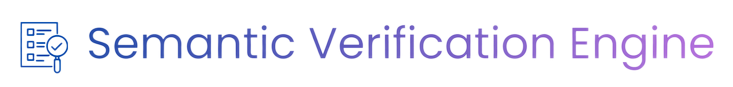

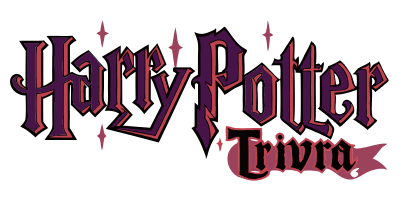

<div style="background-color: #f0e6f7; padding: 10px;">
    <h3 style="text-align:center; color:purple;">Tracer: Runtime game answer evaluation walkthrough & test </h3>
</div>

## 1: Executive Summary

### 1.1. System overview 
This notebook is part of the initial **Tracer Build** of the **Semantic Verification Engine (SVE)**, demonstrating the core runtime logic through a *Harry Potter trivia game* reference implementation. 

The goal here is to use the constrained trivia domain to demonstrate what a **production-style semantic evaluation system looks like when designed and validated under real engineering constraints**. The focus is less on the game itself and more on how data validation, enrichment, and integrity are handled when approached with that level of rigor.

The system evaluates player answers based on *semantic correctness* while maintaining *low latency, CPU-only execution, and deterministic behavior*. To satisfy these constraints without sacrificing reasoning depth, the architecture adopts a *“shift intelligence left”* strategy: 
> **All complex semantic processing is performed offline, leaving runtime execution lightweight, predictable, and fast.** 

![schematic of highlevel abstracted architecture block diagram showing offline vs runtime subsystems of SVE](../../../assets/docs/phase2/highlevel_scheme.jpg)

<p>
  <em>
    <b>Figure-1:</b> high-level scheme of the SVE architecture. The highlighted section reflects the scope of this notebook.<br>
    <small>Note: Legacy data refers to validated & corrected Hugging Face dataset from the project discovery phase.</small>
  </em>
</p>

#### Offline Subsystems (semantic preparation layer)
The offline subsystems are responsible for constructing a **fully validated semantic payload** ahead of runtime and keep it lightweight and detrministic. This includes:
- [**Content generation**](01_tracer_generation_pipeline.ipynb) produce high-quality synthetic questions enriched with core lore concepts, source and entities references grounded in source text.
- [**Multi-stage validation (medallion architecture)**](02_medallion_data_validation.ipynb) An adapted medallion pattern (Bronze → Silver → Gold) standardizes, validates (RAG-Triad + semantic deduplication), and distills content into lightweight, runtime-ready semantic payloads. 
- **Semantic precomputation**: Generate SBERT embeddings and other reusable signals for runtime evaluation.
- **Knowledge packaging**: prebuilding structured hints and explanations to eliminate need for repetitive LLM calls during gameplay.
- [**Contextual enrichment**](03_context_feature_layer_foundation.ipynb): adding domain-specific features for a deeper context-aware evaluation. 

#### Runtime Engine (lean evaluation layer) 

At runtime, the system operates exclusively on the **prevalidated dataset**:
- Question bank is sampled from Parquet and cast into **Question Data Transfer Objects (DTOs) using Pydantic**.
- Evaluation is executed through **deterministic routing and modular evaluators**.
- **LLM usage is restricted** to edge case resolution only. Since the conversational intelligence (questions, hints, explanations) is prebaked offline and the game enforces a strict, turn-based structure (rather than open chat), the runtime does not require an LLM to drive the game state. 

This ensures **predictable latency**, **traceable decision paths**, and **robust, error-resistant execution**.

#### LLM service note
The Tracer MVP uses a **free-tier API provider** for cost-effective validation of the system logic. As a result observed response times may vary and latency variability is expected in this environment. In a production environment, latency targets (e.g. P90 < 500ms) would be achieved by shifting to the paid-tier or self-hosting optimized models.

Refer to the [Design Doc ↗](../../docs/00_DESIGN_DOC_AND_ARCHITECTURE.md) for full architectural details.

### 1.2: Current scope
This notebook demonstrates the runtime evaluation engine - the primary interface of the system. 

It isolates and tests the core end-to-end player answer evaluation routing logic and data lifecycle within the runtime CLI-MVP application. It purposefully bypasses the Game Controller and CLI interface to directly validate the accuracy and performance of the master router and the tiered evaluators (a decoupled test from the main game). 

**Notebook workflow**:
- [Highlevel game considerations ](#2-game-runtime-considerations): brief explanation of the runtime logic.
- [Application start and game warmup](#3-runtime-application-and-game-startup): establish secure network handshakes and compiling structured JSON schemas to absorb API cold-starts. Perform upfront hydration of the dataset SBERT embeddings into tensors, ready for in-game evaluation.
- [Game loop and player answer evaluation](#4-game-loop-player-answer-evaluation): confirm master router and evaluator performance in sequence with test suite of player answers and verify they are scored and correctly categorized into proper resolution tiers (e.g. mcq_exact, ex_llm_judge_pass).
- [Graceful system shutdown](#5-graceful-system-shutdown): resource management -> use garbage collection to clear RAM and close LLM server connections after the game to prevent memory leaks in the cloud VM (virtual machine).  

### 1.3: Answer evaluation architecture
The player provides open-ended responses that are routed through to the correct evaluator. The evaluators are specialized by question or answer types with a hybrid approach that combines deterministic methods, local NLP inference, and LLM-based reasoning as a final fallback. 

This structure balances low latency and deterministic behaviour with the ability to handle natural language variation, spelling differences, and multi-part explanations. 

**Router logic**:

1. **Payload ingestion**: The engine receives the `player_answer` alongside the full `Question` object context.
2. **Master evaluation router**: The payload is inspected and split into one of two primary pipelines based on the question's requirement.
3. **Pipeline A: deterministic subrouter**
    - Evaluates strict data types based on the Question answer_type (numeric, date, year).
    - Resolves via exact-match and strict typecasting (near-zero latency).
4. **Pipeline B: semantic subrouter**
    - Routes by question type: Explanatory (EX), Factual Recall (FR), and Multiple Choice Questions (MCQ).
    - Uses tiered hybrid logic. Attempts local NLP matching first (e.g. exact → fuzzy → SBERT cosine similarity).
    - LLM escalation for EX and FR verbose outliers LLM Escalation. Only if local semantic thresholds fail or require complex reasoning validation.

**Evaluator calibration note**:<br> The thresholds and evaluator behaviors demonstrated in this notebook (e.g. fuzzy match cutoffs, SBERT similarity floors, and LLM escalation conditions) were set through a separate set of experimental workflows. For the Tracer build, the goal was to validate the vertical-slice (end to end) logic and architectural direction. These experiments focused on high-level:
- threshold iterations across question types (MCQ, FR, EX)
- evaluating trade-offs between false positives and false negatives
- comparing evaluator performance (fuzzy matching, SBERT, NLI, LLM)
Further threshold tuning and optimizations are deferred to later development stage. 

**Architecture baseline assessment**:<br>
The current notebook demonstrates a typical runtime gameplay flow.  
Separately, because EX questions represent the highest semantic complexity, the EX evaluator was benchmarked under three configurations using a small randomized set of edge-case responses (~42 evaluations total). These evaluations intentionally emphasized ambiguous and boundary-case answers designed to stress the evaluator:

- *Local inference only*: low latency and deterministic, but underperformed on nuanced reasoning cases (~56% accuracy, ~0.05s average latency)
- *LLM-only evaluation*: improved semantic reasoning (~80% accuracy), but suffered from unstable latency (~21s average latency) and intermittent API failures (e.g. 503 responses / timeout behavior)
- *Hybrid evaluation*: retained near-LLM accuracy (~80%) while reducing average latency (~13s) by resolving ~66% of cases locally before LLM escalation. 

These experiments validated the architectural direction, exhaustive benchmarking is deferred to later development stages.

To keep this notebook focused on **runtime behavior and system flow**, those experiments are not included here. See [`02_research/` nlp labs notebooks](../02_research/) for the underlying evaluation and tuning work.    

### 1.4: Results & Observations
The end-to-end evaluation log demonstrates that the routers and evaluators behaves as designed. The integration test successfully processed a relatively higher complexity sample batch (60% Explanatory questions) without errors.

- **Evaluation accuracy**: All evaluators correctly categorized the test cases. Standard FR and MCQ questions were fully resolved via local inference (exact and fuzzy matching), while verbose EX edge cases correctly escalated to the LLM.
- **Latency & cold-start mitigation**: The game start API initialization sequence with a warmup ping successfully absorbed the API cold start penalty. As a result, the baseline LLM execution time averaged ~1 seconds per call, confirming the efficiency of the routing logic.
- **Free-Tier variability**: During stress testing, lantency spikes were seen with some LLM calls (up to ~19s). This variability can be expected when using the free-tier AI Studio, which is susceptible to server-side queuing. This is acceptable for the Tracer notebook and MVP Demo.
<br><br>

### 1.5: Known limitations & planned mitigations
While the SVE Tracer validates the core architectural routing, several limitations remain in the current evaluator design. These primarily arise from trade-offs between determinism, latency, and semantic flexibility, and will be addressed in future iterations.

| **Observed Limitation** | **Root Cause** | **Planned Mitigation** |
|---|---|---|
| *Domain misalignment (embeddings)*| Pretrained SBERT embeddings are not aligned with domain-specific semantics (Harry Potter lore) | Fine-tune SBERT or augment with a lightweight knowledge graph to improve relational understanding |
| *LLM grading leniency* | LLM judge exhibits a bias towards partial correctness and positive scoring | Add few-shot examples (especially *near-misses*) to better calibrate what counts as correct vs incorrect|
| *Multipart answer ambiguity*| Evaluators consider holistic answers without structured decomposition | *Atomic Claim Matrix*: evolve the existing offline `semantic_lore_concepts` into a strict grading rubric. Transition the LLM Judge from holistic grading to deterministic checklist scoring (e.g. requiring 3/4 core claims to pass).|
| *Reasoning limits / Bias drift*| model likely struggled with multi-step reasoning or fell back on prior assumptions | Use few-shot Chain-of-Thought with targeted negative examples to guide LLM judge to better reasoning|
|*NLI signal weakness*| Off-the-shelf NLI models lack precision for long-form, high-variance answers | Revisit NLI only after claim decomposition; otherwise prioritize LLM escalation for complex semantic validation |
|*Entity resolution gaps*| Player use of aliases (e.g. "Dark Lord" vs. "Voldemort") can artificially lowers SBERT cosine similarity scores | *Localized Key-Value canonicalizer*: Shift alias mapping entirely offline by injecting a question-specific Key-Value dictionary (Alias → Canonical) into the `semantic_entity_refs` payload. At runtime, the engine performs an instant O(1) local lookup to standardize entities before SBERT, maintaining strict latency targets.|
|*High variability in player answers*| Free-text answers can drift away from the expected semantic space | Guide players toward more structured answers (UX nudges) and log valid edge cases to continuously expand accepted `answer_variations` |

### 1.6: Next steps
1. Upgrade to FastAPI deployment: Currently the demo is deployed as a VM with Gotty / websockets for rapid deployment and minimal modification to the CLI game.  Shifting to FastAPI allows for 1-many end points and also gives concurrency flexibility so multiple users can play the game at the same time. A more scalable architecture aligned with the planned system architecture.
2. User testing & telemetry: collect gameplay feedback, latency metrics, and runtime performance data through structured logging and usage monitoring (e.g. Google Cloud console). Observe friction points, evaluator failures, and user behavior patterns to guide future system improvements and calibration.
<br><br>

---

#### Imports and setup

In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2

import random
import json
import gc
import pyarrow.parquet as pq

# --- Core Libraries ---
import pandas as pd
from IPython.display import display
# --- Project-Specific Imports ---
import core.models as pyd
from core.embeddings import get_sbert_model
from core.enforce_schema import enforce_schema_pipeline
import notebook_support.notebook_config as nb_cfg
import notebook_support.tracer_nlp_lab_v0 as lab

✅ Notebook config loaded.


In [2]:
RANDOM_SEED = 26

**Upload dataset**: (ProductionStandard_Green model) For the tracer this is the Gold dataset v1 enriched with descriptive features. NER and other contextual feature were deferred to later development.

In [ ]:
# load the legacy and synthetic tracer datasets
filename = "tracer_production_green_v1.parquet"
df = pd.read_parquet(nb_cfg.FINAL_DATA_DIR / filename)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 33 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   mcq_options                                 45 non-null     object 
 1   question_type                               139 non-null    object 
 2   question_source                             139 non-null    object 
 3   question                                    139 non-null    object 
 4   answer                                      139 non-null    object 
 5   answer_variations                           139 non-null    object 
 6   hint_1                                      139 non-null    object 
 7   hint_2                                      139 non-null    object 
 8   hint_3                                      139 non-null    object 
 9   explanation                                 139 non-null    object 
 10  semantic_entit

The Tracer dataset is designed with a balanced distribution across three question types:
- **Factual Recall (FR):** Short-form answers (typically 1–3 words) focused on specific factual details.  
- **Multiple Choice (MCQ):** Questions where the player selects the correct answer from four given options.  
- **Explanatory (EX):** Open-ended questions that require longer, more descriptive answers involving reasoning or explanation.

In [4]:
# distriubiton of question types in the dataset
df['question_type'].value_counts()

question_type
FR     49
MCQ    45
EX     45
Name: count, dtype: int64

---

## 2: Game runtime considerations

1. **Runtime contract guarantee**
- Docker image contains a prevalidated immutable dataset artifact.
- Dataset has already passed offline schema validation against:
    - ProductionStandard_Green
    - ProductionMCQ_Green
- The startup assumes schema correctnes of the local dataset at container boot.
- Startup validation is for detecting hydration or packaging issues (e.g. missing / malformed tensor columns) and is carried out using its own dedicated runtime schemas.

2. **Data lifecycle: storage, hydration, and scaling**
- *Dataset at rest (parquet base)*: the Production (green/blue) dataset (Tracer: ~139 questions, anticipated full series coverage: ~6K questions) stores the precomputed embeddings as `List[float]` needed for local sbert inference at runtime. This eliminates the embedding compute load at startup. The full dataset size (~6k questions would be ~9MB) that can still be comfortambly handled by the Cloud RAM. The bottle neck would still be models themseleves (SBERT ~100MB).

- *Hydration to Tensors (zero-math conversion)*: During the session warmup, the embeddings will by hydrated into `torch.float32` tensors, ready for SBERT inference. This is a memory-allocation cast that takes milliseconds without any CPU or SBERT calculation overhead.  Since SBERT is required for player input encoding, the PyTorch library is already a dependency.

- *Path to scaling (stateless runtime)*: by decoupling the hydration from the storage, the runtime application can remain lean and stable. For a different use case (beyond reference implementation) that, for example, requires scaling to ~1 million rows, the local Parquet file can be swapped with a VectorDB API call. The database would return a randomly sampled N data payload to the runtime application. The embeddings would be hydrated the same way and passed exactly as before.

3. **State Management with shuffled pool sampling**. To maintain game flow and variety, the game will load a question bank upfront (full tracer or preset size set of e.g. 500 questions) for a given session. 
    - An `available_indices` list will be generated and shuffled at the start of the session.
    - For sampling: questions are popped from the list without replacement ($n=10$ per round, O(1) time efficiency). This guarantees a unique experience across a mulitple rounds.It simplifies state management since the engine doesn't need to track a seen list.

4. **Semantic verification logic (tiered hierarchy)**. Logic follows a hierarchical approach to balance speed and semantic depth for all question types (with variations to adapt to the specifics of each type). Tiers will be adapted to each question type and consist of *exact match, fuzzy match, sbert similarity, NLI (Natural Language Inference; disabled for the Tracer), and final resolution with LLM API calls*.  

5. **End of road strategy considerations**. when player has used up all the bank in a session, can consider different options to handle game state:
    1. *Graceful end*: needed with tracer (in case player uses up all ~139 questions). Display a "check back in future" message for expanded or full game.
    2. *Spaced repetition*: A new challenge run made up of all the questions they had gotten wrong in the session and then gracefully end. Useful for other uses cases of the system, e.g. MCAT prep, that need spaced repetition.
    3. *Competitive resuffle*: when Gold dataset is larger than gametime bank, load a new non-repetitive bank of questions but with increased difficulty / challenge / theme etc.

>**NOTE**: precomputing embeddings offline prevents CPU bottlenecks during concurrent session loads. The runtime simply converts the stored arrays into PyTorch tensors (low cost memory allocation) reserving SBERT inference mainly for live player answer encoding. This design maintains consistent, low-latency load times.

## 3: Runtime application and game startup
Runtime environtment: 
- Runtime executes inside a controlled containerized environment.
- Dataset artifacts are immutable during execution.
- Tensor corruption is considered low probability because of offline validation and closed-container deployment.
- Failure recovery methods are not implemented for the tracer stage.

### 3.1: Application warmup (container initialization / global setup)
1. Load models (SBERT, NLI cross-encoder if used). Models loaded into the RAM once instead of every call.
2. Read parquet as pyarrow table and then convert into pandas dataframe.
3. Hydrate dataset (convert embeddings from List[Float] to torch.float32)
4. Validated and hydrate paraquet dataset with Runtime pydantic model.
5. Initialize the LLM API (Gemini/AI Studio for Tracer) client at container startup (handshake and service authentication once).

In [ ]:
## Application start 

# setup (columns to be hydrated into tensors)
emb_cols = ['question_embeddings', 'answer_embeddings']
emb_list_cols = ['answer_variations_embeddings', 'mcq_distractors_embeddings']  # 'source_quote_embeddings' not required for game

# 1. load sbert model
local_model = get_sbert_model()  # loaded model from singleton cache (SBERT & NLI models defined centrally in embeddings.py)
local_model.encode("warmup")     # warmup the model to avoid first-call latency during the game.
# nli_model = get_nli_model()    # NLI disabled for tracer demo, will be reconsidered in full development.

# 2. read parquet as pyarrow table, convert to pd.dataframe, validate and hydrate with pydantic model
path = nb_cfg.FINAL_DATA_DIR / filename
runtime_table =  pq.read_table(path)
unvalidated_runtime_df = runtime_table.to_pandas()

# 3. hydrate tensors for the entire tracer dataset
unvalidated_runtime_df = lab.prepare_runtime_tensors(dataframe=unvalidated_runtime_df,
                                     embedding_col_names=emb_cols,
                                     embedding_list_cols_names=emb_list_cols)

# tensor sanity checks
new_cols = [f"{col}_tensor" for col in emb_cols] + [f"{col}_tensor_matrix" for col in emb_list_cols]
assert set(new_cols).issubset(set(unvalidated_runtime_df.columns)), "CRITICAL: Not all tensor columns were created successfully!"
unvalidated_runtime_df[['master_id','question','question_embeddings_tensor','answer_embeddings_tensor',
            'answer_variations_embeddings_tensor_matrix','mcq_distractors_embeddings_tensor_matrix']].head()

# tensor visual check: display df head to confirm hydration visually
unvalidated_runtime_df[['master_id','question','question_embeddings_tensor','answer_embeddings_tensor',
            'answer_variations_embeddings_tensor_matrix','mcq_distractors_embeddings_tensor_matrix']].head()

# 4. validate with Pyndantic model
runtime_df, runtime_flagged = enforce_schema_pipeline(df=unvalidated_runtime_df,mode="dev")

# sanity check (visual check)
runtime_df.head()

,mcq_options,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,...,answer_length,answer_type,question_tokens,answer_tokens,combined_unique_tokens,main_keyword,question_embeddings_tensor,answer_embeddings_tensor,answer_variations_embeddings_tensor_matrix,mcq_distractors_embeddings_tensor_matrix
0,"[seeker for gryffindor, spew treasurer, quiddi...",MCQ,legacy,Which of these titles or identities has NOT be...,spew treasurer,"[spew treasurer, spew, treasurer]",Consider the various clubs and organizations a...,Think about Hermione Granger's passion for hou...,This particular role was specific to an organi...,Harry Potter was a Seeker and Quidditch Captai...,...,2,text,"[which, title, identity, have, be, hold, harry...","[spew, treasurer]","[which, title, identity, have, be, hold, harry...",which,"[tensor(-0.0692), tensor(0.0238), tensor(0.011...","[tensor(-0.0500), tensor(-0.0012), tensor(-0.0...","[[tensor(-0.0500), tensor(-0.0012), tensor(-0....","[[tensor(-0.0475), tensor(0.0124), tensor(0.03..."
1,"[sectumsempra, confringo, crucio, reducto]",MCQ,legacy,Which of the following spells is considered on...,crucio,"[crucio, cruciatus]",Recall the darkest and most feared spells that...,"One of these spells causes intense, agonizing ...",This curse is often used by followers of the D...,"The Cruciatus Curse, 'Crucio', is one of the t...",...,1,text,"[which, following, spell, be, consider, one, t...",[crucio],"[which, following, spell, be, consider, one, t...",which,"[tensor(0.0045), tensor(0.0814), tensor(-0.138...","[tensor(-0.0346), tensor(0.0673), tensor(-0.06...","[[tensor(-0.0346), tensor(0.0673), tensor(-0.0...","[[tensor(0.0001), tensor(0.0421), tensor(-0.11..."
2,[whispering in the library without being overh...,MCQ,legacy,In which of these scenarios would you use the ...,whispering in the library without being overheard,"[whispering, not being overheard, whispering i...",Think about spells that affect sound or privacy.,This charm fills the ears of anyone nearby wit...,It's perfect for having a secret conversation ...,The Muffliato Charm is used to fill the ears o...,...,7,text,"[which, scenario, would, use, muffliato, charm]","[whisper, library, without, be, overheard]","[which, scenario, would, use, muffliato, charm...",which,"[tensor(-0.0361), tensor(-0.0051), tensor(0.03...","[tensor(-0.0154), tensor(-0.0675), tensor(0.05...","[[tensor(-0.0444), tensor(-0.0519), tensor(0.0...","[[tensor(0.0041), tensor(0.1337), tensor(0.029..."
3,"[godric gryffindor, salazar slytherin, helena ...",MCQ,legacy,Which one of the following is not a founder of...,helena ravenclaw,"[helena ravenclaw, ravenclaw]",Consider the four names associated with the Ho...,One of these individuals is the daughter of a ...,"This person is also known as the Grey Lady, th...",The four founders of Hogwarts are Godric Gryff...,...,2,text,"[which, one, following, be, founder, hogwarts]","[helena, ravenclaw]","[which, one, following, be, founder, hogwarts,...",which,"[tensor(-2.1572e-05), tensor(0.0080), tensor(-...","[tensor(-0.0344), tensor(-0.0454), tensor(-0.0...","[[tensor(-0.0344), tensor(-0.0454), tensor(-0....","[[tensor(0.0039), tensor(0.0123), tensor(0.017..."
4,"[concentration, wand power, hue of the object,...",MCQ,legacy,Which of these factors does NOT affect Transfi...,hue of the object,"[hue, color]",Think about the essential elements required fo...,Transfiguration spells primarily depend on the...,While the final product might have a specific ...,"Factors like concentration, wand power, and th...",...,4,text,"[which, factor, do, affect, transfiguration]","[hue, object]","[which, factor, do, affect, transfiguration, h...",which,"[tensor(0.0682), tensor(-0.0122), tensor(-0.00...","[tensor(0.0669), tensor(0.1001), tensor(0.0268...","[[tensor(-0.0157), tensor(0.0926), tensor(-0.0...","[[tensor(0.1058), tensor(-0.0057), tensor(-0.0..."


**LLM API call latency mitigation and cold-start management**:
The LLM call is initialized at the start of the game to absorb the cold-start latency upfront and ensure a smoother UX during the game loop through three key steps:
1. *Network handshake*: establish and then keep the secure LLM API connection warm for the duration of the session.
2. *LLM response schema*: Send a warmup ping formatted with the `LLMJudgeResponse` schema so the server can compile and cache the structured output schema upfront.
3. *Cache system prompt*: the warmup ping also provides the system prompt for the EX evaluations (most frequent LLM escalation path). FR questions can also escalate to LLM but it is only needed for outlier / edge cases and trigger likely an low probability ~one-time compilation delay within a session. 

In [6]:
# 5. Initialize game session LLM connection.
lab.warmup_llm_connection()

--- Initiating LLM Network Handshake ---
Target: models/gemini-3.1-flash-lite-preview


E0000 00:00:1779032510.778307 30906964 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


✅ Connection established. Warmup time: 1.14 seconds.
The network pipe is now open for _call_llm_judge.



For the tracer startup, actions are as follows:

||**Hard failures (startup abort)**| **Soft failures (degraded runtime)**|
|-|-|-|
|**Runtime behavior**| Game session does not start |Runtime continues in reduced-capability mode|
|**Classification**|infrastructure/runtime integrity failures|capability signal only|
|**Conditions**|- SBERT warmup encoding fails <br>- required tensor hydration fails<br>- required tensor columns are missing/null <br>- dataset artifact cannot be loaded| Determined by LLM warmup outcome: <br>- *OK*: Normal runtime operation <br> - *Degraded*: Slow response / timeout / transient API instability <br> - *Failed*: LLM connection unavailable|
|**Runtime handling**|Startup abort (stop game)|- FR evaluators continue using local semantic inference <br>- EX evaluators may operate in reduced-capability mode<br>- Game controller determines UX handling and evaluator policy|

### 3.2: Game session start
1. Generate and maintain a shuffled *available_indicies* list from the global question bank (full tracer or selected *production* dataset).
2. Pop top N (=10 for tracer) question based on the *available indicies* list without replacement for the active session run.
3. Map sampled rows to Question objects and pass to game controller.
4. If new session is requested, repeat the sampling logic from the remaining `available_indices`.
5. Allow for graceful termination:
    - *Normal game*: game standard summary and goodbye message.
    - *Question bank exhaustion*: If `available_indices` is empty, trigger a "check back later" message, providing a clear boundary for the Tracer deployment.

In [7]:
## Session start
N = 10  # number of questions to pop for the session (tracer will use 10)

# 1. generate shuffled available_indices list to track which questions remain for next session.
available_indices = list(runtime_df['master_id'])
random.Random(RANDOM_SEED).shuffle(available_indices)

# 2. pop top N indices for the session (tracer will use 10) 
session_indices = [available_indices.pop() for _ in range(N)]

# 3. retrieve questions from dataframe for the session
session_df = runtime_df[runtime_df['master_id'].isin(session_indices)]

# 4. convert to list of Question ojbects for the session
session_questions = []
for row_dict in session_df.to_dict('records'):
    q = lab.question_factory(row_dict)
    session_questions.append(q)

Confirm that the Question objects were created properly.

In [8]:
## sanity checks of the session_questions list

# 1. confirm N questions
assert len(session_questions) == N, f"Expected {N} questions, but generated {len(session_questions)}"

# 2. confirm against Pydantic models for the question objects
#    Since using "dev" (default) mode in `question_factory` -> using Production Green model.
valid_pydantic_classes = (pyd.ProductionStandard_Green, pyd.ProductionMCQ_Green) 
for q in session_questions:
    # verify is instance of correct Pydantic model
    assert isinstance(q, valid_pydantic_classes), f"ID {getattr(q, 'master_id', 'Unknown')} is an invalid type: {type(q)}"
    # match master id
    assert q.master_id in session_indices, f"Question ID {q.master_id} was not in the original sampled session indices."

## 4: Game loop: player answer evaluation

### 4.1: Session 1

Review the `session_questions` data by filtering the dataframe and generate test player answers to test the routing and evaluators.

In [9]:
## review records in session_questions list
runtime_df[runtime_df['master_id'].isin(session_indices)][['master_id','question_source','question_type','question','answer','answer_variations']]

,master_id,question_source,question_type,question,answer,answer_variations
10,IsYzSBEV,legacy,MCQ,Which of these spells keeps a charm stable:,fianto duri,"[fianto duri, duri]"
14,wkx20Rmx,legacy,MCQ,Which of the following creatures eat fairy eggs:,bowtruckles,"[bowtruckles, bowtruckle]"
32,D2npylmT,legacy,EX,Who can master a wand with a Thestral tail hai...,one who has faced death,[only a wizard or witch who has truly faced an...
43,AtnKZQYE,legacy,EX,"In Half-Blood Prince, why did Professor Slugho...",because he was impressed by her exceptional ma...,[professor slughorn invited ginny to the slug ...
51,KA18fl4n,legacy,EX,How is the Grey Lady related to Rowena Ravenclaw?,she's rowena's daughter.,"[the grey lady, helena ravenclaw, is the biolo..."
52,chwNLtpK,legacy,EX,Harry discovers he’s one of Voldemort’s seven ...,"tom riddle’s diary, nagini, the gaunt ring, th...","[the other horcruxes are tom riddle’s diary, n..."
109,FFBjZ64Q,synthetic,EX,Why did Lord Voldemort order Nagini to kill Se...,voldemort mistakenly believed that because sna...,[voldemort believed snape was the elder wand's...
110,Z6wdYgLD,synthetic,EX,Why did Albus Dumbledore explicitly ask Severu...,dumbledore wanted to protect draco malfoy's so...,"[dumbledore asked snape to kill him, protectin..."
122,X1L_VOIf,synthetic,FR,"According to Dumbledore's portrait, under what...",need and valor,"[need and valor, valor and need, need, valor]"
128,DhG2J0H4,synthetic,MCQ,What was Professor McGonagall's correct answer...,"into non being, which is to say, everything.","[non being, everything]"


Test player answers for the session 1 questions:

In [10]:
## test player answers

player_answers = [
    # happy path confirmation (exact match)
    'fianto duri',
    'bowtruckles',
    'one who has faced death',
    
    # semantic variance
    'Slughorn saw Ginny use her bat-boogey hex on the train and thought she was talented enough to join his club.',
    
    # slight variations
    "   She was her daughter !!!!!", # normalization
    'riddles diary, gaunt ring, his pet snake nagini, slytherins locket, rowenas diadem and hufflepuff cup',
    "he thought snape was the master of the elder wand because he killed dumbledore. so to fully control the wand he had to kill snape.",
    "dumbledore wanted to protect draco from committing murder. he believed snape could better bear the burden and give him a dignfied end.",    
    "need and valour",  # Canadian, UK spelling
    
    # reslience check with incorrect answer (expected to fail) 
    "i have no idea?!"
]

This loop simulates the player answering the 10 sessions questions with the test answers. The evaluators return a structured output (Pydantic DTOs) with tracking telemetry.

In [11]:
# run session 1 game loop 

game_results = []
i=1
for question_obj, player_answer in zip(session_questions, player_answers):

    result = lab.evaluation_router(player_answer, question_obj)
    game_results.append({
        'master_id': question_obj.master_id,
        'ques_type': question_obj.question_type,
        'result_obj': result
        })
    status = "✅ PASS" if result.is_correct == True else "❌ FAIL"
    print(f"{i}. {status} | TYPE: {question_obj.question_type} | ID: {question_obj.master_id} | Resolution Tier: {result.resolution_tier}\n")
    i+=1

1. ✅ PASS | TYPE: MCQ | ID: IsYzSBEV | Resolution Tier: mcq_exact

2. ✅ PASS | TYPE: MCQ | ID: wkx20Rmx | Resolution Tier: mcq_exact

3. ✅ PASS | TYPE: EX | ID: D2npylmT | Resolution Tier: ex_exact

--- Escalating to LLM Judge ---
LLM resolution time: 1.13 seconds
4. ✅ PASS | TYPE: EX | ID: AtnKZQYE | Resolution Tier: ex_llm_judge_pass

--- Escalating to LLM Judge ---
LLM resolution time: 1.52 seconds
5. ✅ PASS | TYPE: EX | ID: KA18fl4n | Resolution Tier: ex_llm_judge_pass

--- Escalating to LLM Judge ---
LLM resolution time: 9.89 seconds
6. ✅ PASS | TYPE: EX | ID: chwNLtpK | Resolution Tier: ex_llm_judge_pass

--- Escalating to LLM Judge ---
LLM resolution time: 1.78 seconds
7. ✅ PASS | TYPE: EX | ID: FFBjZ64Q | Resolution Tier: ex_llm_judge_pass

--- Escalating to LLM Judge ---
LLM resolution time: 1.27 seconds
8. ✅ PASS | TYPE: EX | ID: Z6wdYgLD | Resolution Tier: ex_llm_judge_pass

9. ✅ PASS | TYPE: FR | ID: X1L_VOIf | Resolution Tier: fr_fuzzy

10. ❌ FAIL | TYPE: MCQ | ID: DhG2J0H

The logs demonstrate that the answers were correctly routed and evaluated:

- **Local inference routing (cases 1-3, 9, 10)**: The FR and MCQ questions here were all resolved through local inference. This includes rapid tier-1 exact matches (cases 1-3), tier-2 fuzzy match (case 9), and correctly failing the invalid MCQ options across all its evaluation tiers.
- **LLM escalation (cases 4-8)**: These were correctly escalated to the LLM Judge as expected for EX-type responses. Each of these followed the intended evaluation pipeline:  *local routing → escalation trigger → LLM evaluation → final verdict (ex_llm_judge_pass)*. This validates that the escalation path is functioning correctly.
- **Latency variance**: LLM evaluation latency for EX cases ranges from ~1s to ~10s under identical prompt structure, consistent payload size, and warm session conditions (with spikes observed upto ~19s). The wide range is likely from the service side conditions (free-tier queing, routing etc). 
- **Distribution note (sampling variance)**: The 10-question sample contained 5 EX cases (50%), which is higher than the overall dataset proportion (~32%), unintentionally providing a heavier stress load on the LLM evaluation pathway.
- **System implication**: The architecture behaves as intended:
     - deterministic routing remains fast and reliable
     - ambiguous semantic answers are correctly delegated to LLM judgment
     - latency is concentrated only in the LLM escalation layer

    Mitigation strategies include:
     - dynamic grading status messages as the evaluation moves through tiers
     - potential migration to higher-tier or self-hosted inference for reduced variance for full development
     - demo expectation management with disclaimer on unpredictable free-tier usage.

#### Review of Evaluator telemetry

Each evaluation is recorded as a structured result object tailored to the specific question type and implemented using Pydantic BaseModels to ensure type-safety and robust telemetry tracking.

- **Multiple Choice (MCQ) Evaluator** does not require LLM calls. The final resolution tier relies on SBERT cosine similarity to verify that the player answer is sufficiently close to the correct answer while remaining distinct from the distractors.
- **Factual Recall (FR) Evaluator**: designed for short-form answers. The evaluator uses a cascade of *exact → fuzzy → SBERT similarity*. It includes a *score boost* for ambiguous answers in case a known entity alias is detected. Only verbose outliers are escalated to the LLM Judge.
- **Explanatory (EX) Evaluator**: designed for high-variance responses. It uses exact and fuzzy for early low-effort catches, followed by SBERT similarity check. Ambiguous answers are escalated to the LLM-Judge tier for the final-tier resolution.

The result tracks the 'correct' flag and identifies which resolution tier the answer reached, alongside Evaluator specific metrics. We can take a closer look at example results for each question type below.

**Note on execution time:** The recored execution time reflects the full evaluation logic. In the cases were LLM calls were triggered, this includes the LLM resolution time (from the evaluation log earlier) plus a mandatory time delay (6 seconds) to manage the free-tier RPM (Request Per Minute) limits.

In [12]:
## display the Evaluation Result objects

result_dto_examples = {}

# loop through the results list
for r in game_results:
    question_type = r['ques_type']
    result_obj = r['result_obj']
    
    # save first example of FR, MCQ
    if question_type in ['FR', 'MCQ'] and question_type not in result_dto_examples:
        result_dto_examples[question_type] = result_obj
    
    # save first example of EX that was resolved by escalating to the LLM judge
    elif question_type =='EX' and question_type not in result_dto_examples:
        if 'llm' in result_obj.resolution_tier:  # filter for example resolved by LLM
            result_dto_examples[question_type] = result_obj
    # make sure there are only 3 examples
    if len(result_dto_examples)==3:
        break

# display ther result data objects as JSON for readability
for question_type, result_object in result_dto_examples.items():
    print(f"\n--- {question_type} Evaluation Object ---")
    print(json.dumps(result_object.model_dump(), indent=2))     


--- MCQ Evaluation Object ---
{
  "is_correct": true,
  "resolution_tier": "mcq_exact",
  "fuzzy_score": 1.0,
  "sim_correct_ans": 0.0,
  "sim_distractor": 0.0,
  "margin": 0.0,
  "matched_variation": false,
  "execution_time_sec": 0.0002
}

--- EX Evaluation Object ---
{
  "is_correct": true,
  "resolution_tier": "ex_llm_judge_pass",
  "fuzzy_score": 0.3768,
  "primary_similarity_score": 0.8152,
  "matched_ans_variation": true,
  "nli_label": "",
  "nli_confidence": 0.0,
  "llm_model_used": "models/gemini-3.1-flash-lite-preview",
  "llm_mc_response": "Spot on! Slughorn certainly knew a talented witch when he saw one, and that hex of hers was exactly what caught his eye.",
  "llm_reasoning": "The player correctly identifies the causal link between Ginny's specific magical ability (the bat-bogey hex) and Slughorn's decision to invite her to the club. The player's mention of the train setting is a minor contextual detail that does not contradict the core logic, and the causal direction\

**MCQ Result (test case 1)**<br>
Resolved immediately at the first tier (`mcq_exact`).
- The player answer matched exactly, so no downstream evaluation was required.
- Fuzzy and semantic scores remain 0 because they were never invoked.
- Execution time is 0.2 ms, reflecting the fastest possible path.

**EX result (test case 4)**<br>
Resolved in the final tuer (`ex_llm_judge_pass`). 

|player answer|*"'Slughorn saw Ginny use her bat-boogey hex on the train and thought she was talented enough to join his club.'"*|
|-|-|
|dataset main answer| *"because he was impressed by her exceptional magical talent, particularly her powerful bat-bogey hex"*|
|matched answer variation|*"professor slughorn invited ginny to the slug club because he was greatly impressed by her exceptional magical talent, specifically her powerful bat-bogey hex."*|

*Evaluation flow*:
- **Tier 1 & 2 (Exact + Fuzzy)**: Failed.<br> 
    Fuzzy score = 0.38, below the EX threshold (0.95). This is expected for longer, free-form answers.
- **Tier 3 (SBERT filter)**: Passed (through filter)<br>
    - matched an answer variation with similarity = 0.82
    - cleared the ambiguity floor (0.40)
    - SBERT acts as a gatekeeper, not a final decision-maker for EX answers.
- **Tier 4 (NLI)**: Skipped<br>
    Disabled in Tracer (null output)
- **Tier 5 (LLM judge)**: Final resolution.<br>
    - Evaluates reasoning against grounded source context
    - Correctly identifies the causal link: *Ginny’s hex → Slughorn’s impression → invitation*
    - Returns `is_correct` = true with structured reasoning
- **Execution time (7s)**: This includes the full Evaluator execution with ~1s LLM inference and 6s free-tier rate limiting buffer.

**FR Result (test case 9)**:<br>
Resolved at the second-tier (`fr_fuzzy`)
- Exact match failed due to spelling variation: “valour” vs “valor”
- Fuzzy score = 0.97, exceeding the FR threshold (0.85)
- Resolved without invoking semantic or LLM layers
- Execution time: 0.3 ms

### 4.2: Session renewal
For a new session:
- if there are questions left in the bank, create a new session.
- otherwise display an end-of-demo goodbye message and ask to checkin again later.

In [13]:
## confirm new session setup (i.e. player wants another round with new questions)

if len(available_indices) < N:
    # graceful handling tracer game en
    print(f"✨And that’s the last question ...for now. ⌛️",
          f"🏆 You’ve completed the demo, but more are on their way! Check back soon for the next round.")

else:
    # get next set of questions using the `available_indices` list
    next_session_indices = [available_indices.pop() for _ in range(N)]

    # sanity checks
    # 1. size N questions
    assert len(next_session_indices) == N, f"Expected {N} questions for next session, but got {len(next_session_indices)}"
    # 2. no overlap with previous session questions
    assert not set(session_indices).intersection(set(next_session_indices)), "CRITICAL: Next session questions overlap with previous session questions!"
    # 3. no overlap with remaining available_indices
    assert not set(next_session_indices).intersection(set(available_indices)), "CRITICAL: Next session questions overlap with remaining available questions pool!"
    # 4. uniquenss against main df 
    assert set(next_session_indices).issubset(set(runtime_df['master_id'])), "CRITICAL: Some Next Session question IDs are not in the main dataframe!"
    print("✅ New session data extraction passed all integrity checks.")

✅ New session data extraction passed all integrity checks.


## 5: Graceful system shutdown
Free cloud VM resources up and spin system down.

In [14]:
print("Initiating graceful shutdown...")

# 1. clear large SBERT model from memory
if 'local_model' in globals():
    del globals()['local_model']
    print("✅ SBERT model removed from memory.")

# 2. close API client (Gemini SDK specific)
# The google.generativeai SDK relies on garbage collection to sever gRPC tunnels.
print("✅ LLM network channels flagged for teardown.")

# 3. Force Python to immediately dump RAM and close orphaned sockets
gc.collect()

print("✅ System safely spun down.")

Initiating graceful shutdown...
✅ SBERT model removed from memory.
✅ LLM network channels flagged for teardown.
✅ System safely spun down.


---

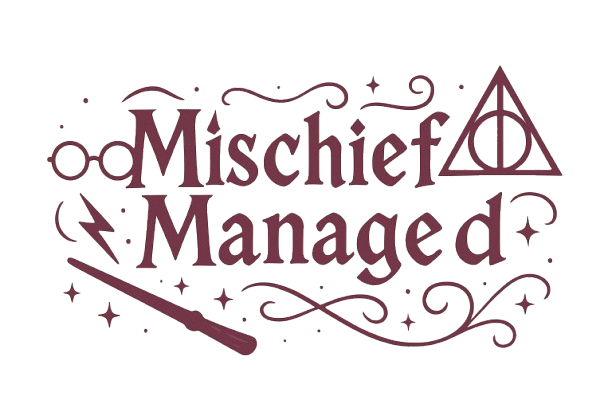